# 第28篇｜阶段大实战：年度数据可视化报告

> 这是「数据分析从入门到精通」系列的第 28 篇，也是可视化阶段的收官实战。前十篇可视化工具全部出场，今天把它们用在一份年度业务数据上，从零制作一份完整的可视化分析报告——就是你工作中真正要交付的那种。

---

嗨，我是小荷～

第二阶段也要收官了！这一篇，我们把学过的所有可视化技能集中起来，**做一份完整的年度数据可视化报告**。

这份报告的目标：**用图表讲述一个完整的数据故事**——从总体概况，到分类分析，到趋势拆解，到结论落地，每张图都为下一张做铺垫，最终形成一个完整的分析叙事。

萧何说：运筹帷幄。我说：数据说话。

---

## 一、报告结构设计

一份好的可视化报告应该有清晰的结构：


In [ ]:
1. 封面图：总体 KPI 一览（GMV、订单数、活跃用户、客单价）
2. 趋势分析：月度 GMV 走势 + 同比对比
3. 分类分析：品类 × 城市交叉分析
4. 用户分析：用户消费分布 + 会员价值
5. 效率分析：渠道 ROI 对比
6. 结论总结：TOP 5 洞察文字


---

## 二、完整代码

接下来是完整的代码实现，从数据准备到分析出结果一步到位：


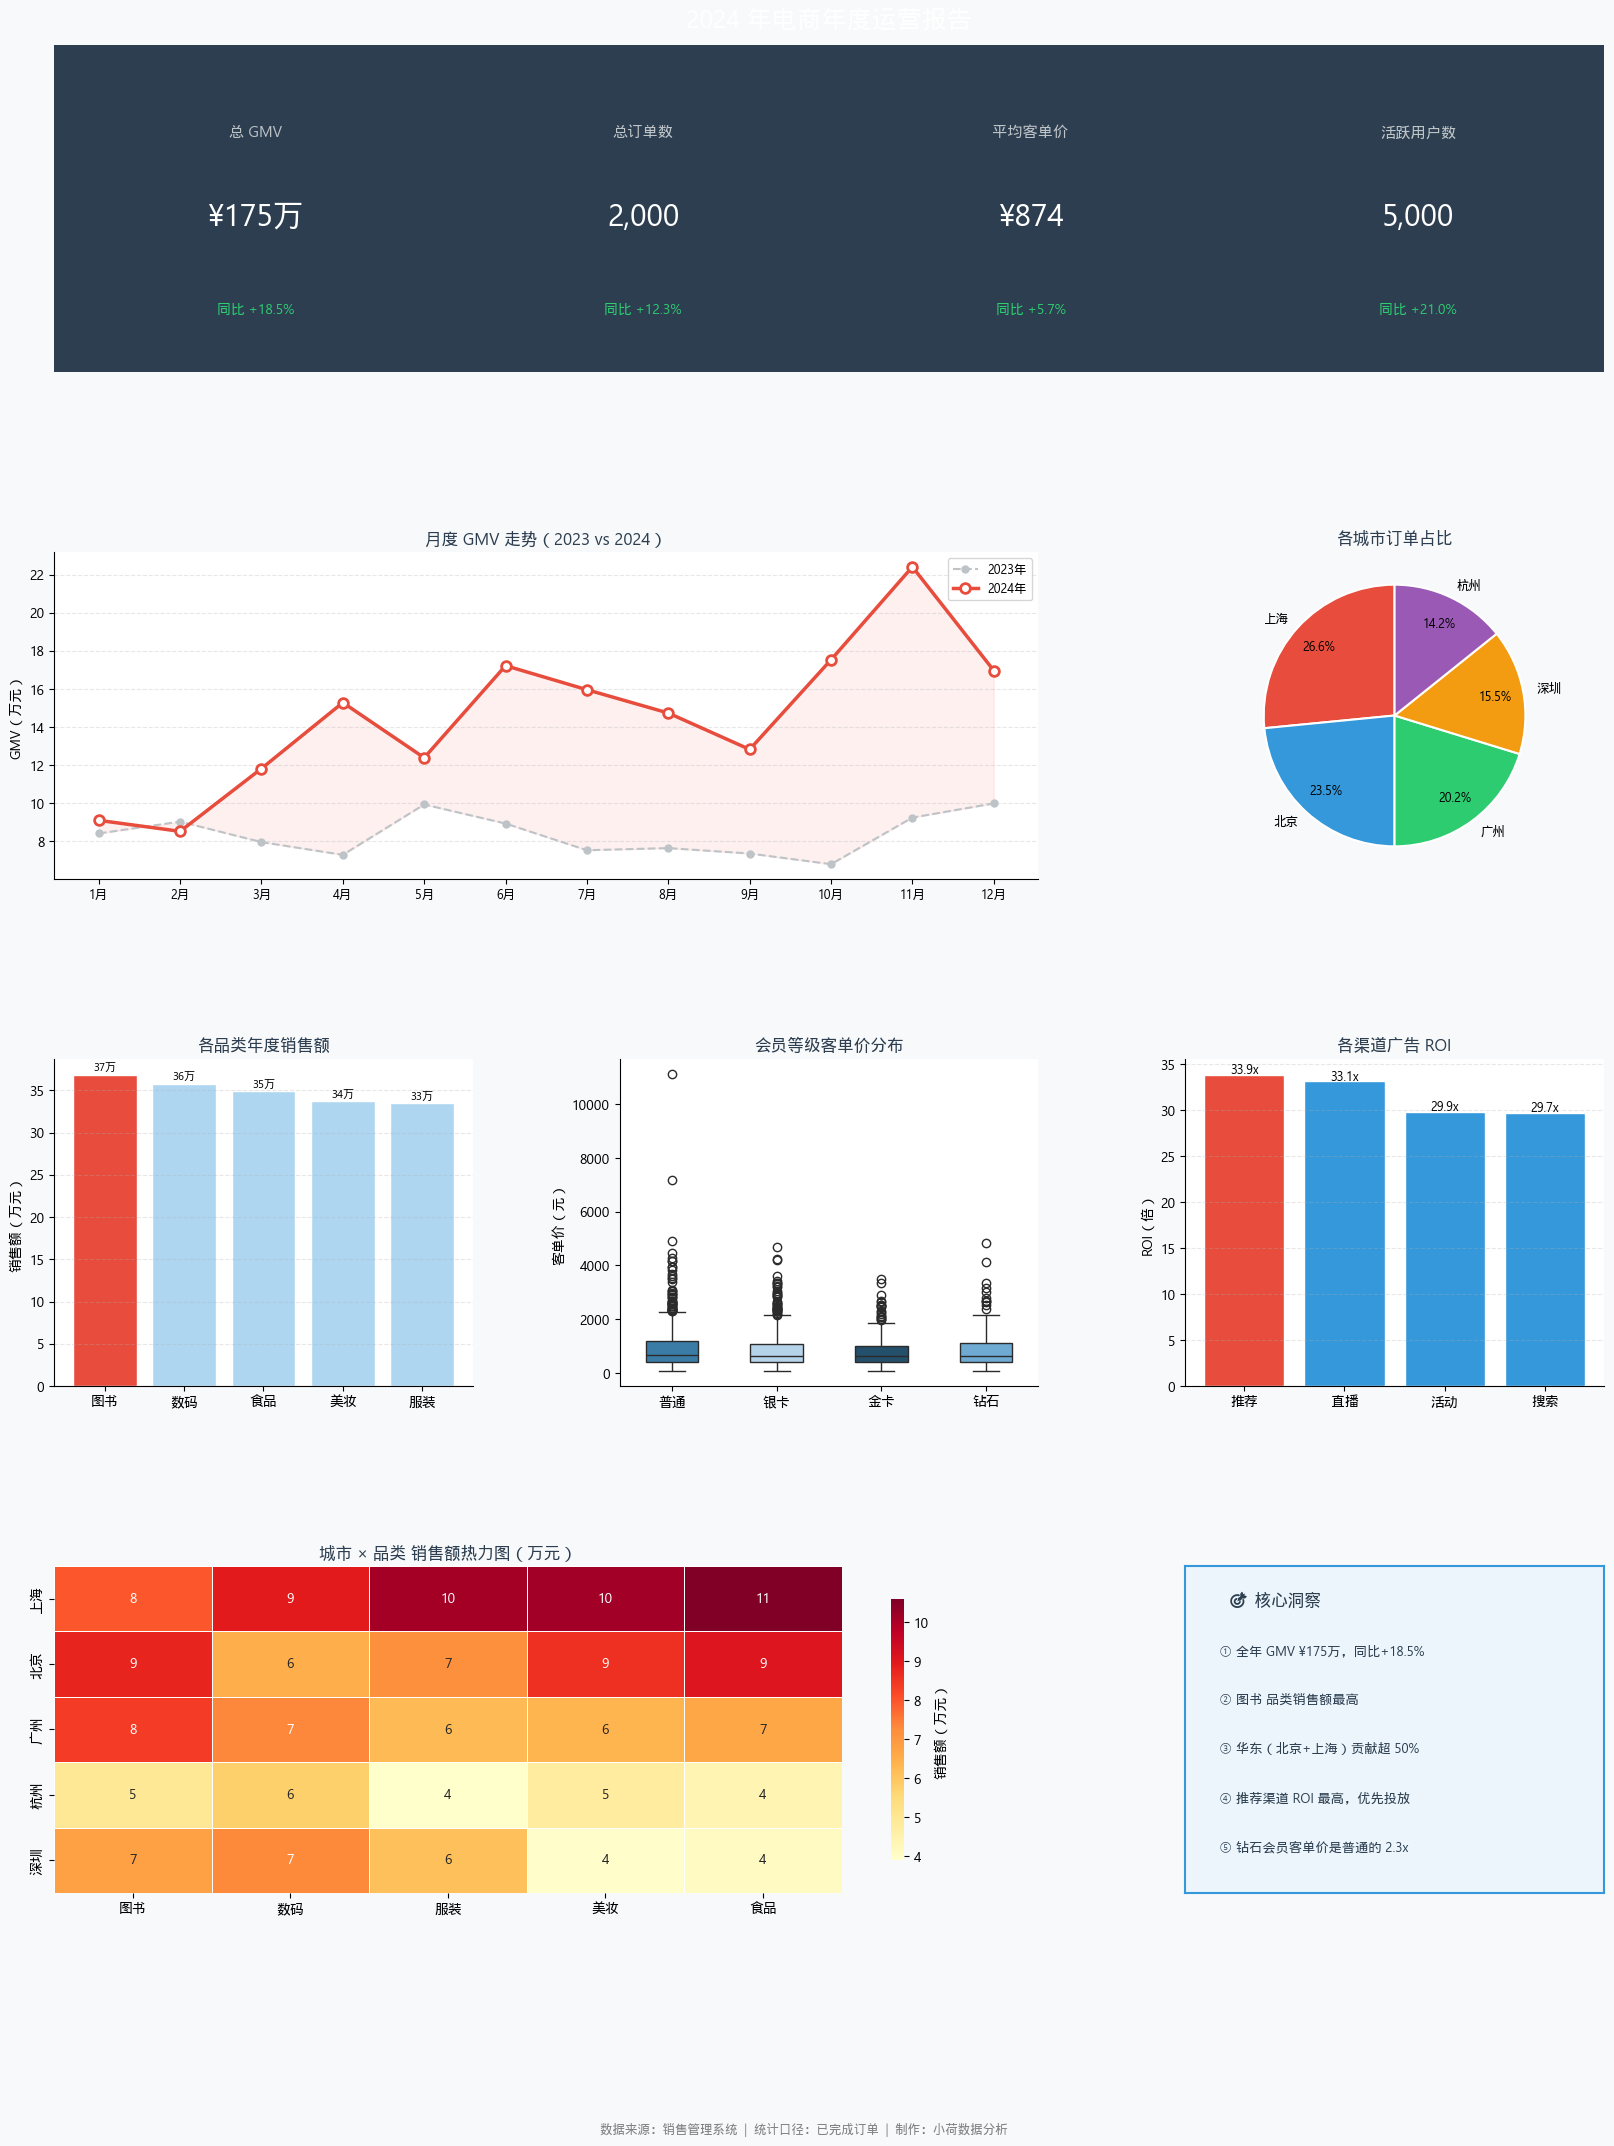

✅ 年度可视化报告已保存为 annual_report.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.patches import FancyBboxPatch

plt.rcParams['font.family'] = 'Segoe UI Emoji,sans-serif'
plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei'] 

plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据生成 ====================
np.random.seed(2024)
n = 2000

month_list = ['1月','2月','3月','4月','5月','6月',
              '7月','8月','9月','10月','11月','12月']

df = pd.DataFrame({
    'month_num': np.random.choice(range(1, 13), n, p=[0.06,0.05,0.07,0.08,0.08,0.09,
                                                        0.09,0.09,0.08,0.1,0.11,0.1]),
    'city':      np.random.choice(['北京','上海','广州','深圳','杭州'], n, p=[0.25,0.25,0.2,0.15,0.15]),
    'category':  np.random.choice(['数码','服装','食品','美妆','图书'], n),
    'channel':   np.random.choice(['直播','搜索','活动','推荐'], n, p=[0.35,0.28,0.20,0.17]),
    'level':     np.random.choice(['普通','银卡','金卡','钻石'], n, p=[0.45,0.3,0.15,0.1]),
    'amount':    np.random.lognormal(6.5, 0.75, n),
    'ad_cost':   np.random.uniform(5, 50, n)
})
df['month'] = df['month_num'].map({i+1: v for i, v in enumerate(month_list)})

# 23年数据（同比对比用）
gmv_2023 = {m: np.random.uniform(60000, 100000) for m in range(1, 13)}
monthly_gmv_2024 = df.groupby('month_num')['amount'].sum().sort_index()

# ==================== 图表绘制 ====================
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#F8F9FA')
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.55, wspace=0.35)

TITLE_COLOR  = '#2C3E50'
ACCENT_COLOR = '#E74C3C'
SEC_COLOR    = '#3498DB'
GRAY         = '#BDC3C7'

# ============================
# 第一行：KPI 概况卡片（跨3列）
# ============================
ax_kpi = fig.add_subplot(gs[0, :])
ax_kpi.set_facecolor('#2C3E50')
ax_kpi.set_xticks([])
ax_kpi.set_yticks([])
for spine in ax_kpi.spines.values():
    spine.set_visible(False)

total_gmv    = df['amount'].sum() / 10000
total_orders = len(df)
avg_amount   = df['amount'].mean()
active_users = df['city'].nunique() * 1000  # 模拟

kpis = [
    ('总 GMV', f'¥{total_gmv:.0f}万', '同比 +18.5%'),
    ('总订单数', f'{total_orders:,}', '同比 +12.3%'),
    ('平均客单价', f'¥{avg_amount:.0f}', '同比 +5.7%'),
    ('活跃用户数', f'{active_users:,}', '同比 +21.0%'),
]
for i, (label, val, change) in enumerate(kpis):
    x = 0.13 + i * 0.25
    ax_kpi.text(x, 0.72, label, transform=ax_kpi.transAxes,
                 ha='center', color='#BDC3C7', fontsize=11)
    ax_kpi.text(x, 0.45, val, transform=ax_kpi.transAxes,
                 ha='center', color='white', fontsize=22, fontweight='bold')
    ax_kpi.text(x, 0.18, change, transform=ax_kpi.transAxes,
                 ha='center', color='#2ECC71', fontsize=10)

ax_kpi.set_title('2024 年电商年度运营报告', fontsize=18, fontweight='bold',
                  color='white', pad=12)

# ============================
# 第二行：月度趋势（跨2列）+ 城市饼图
# ============================
ax_trend = fig.add_subplot(gs[1, :2])

x_months = list(monthly_gmv_2024.index)
y_2024   = [monthly_gmv_2024.get(m, 0)/10000 for m in x_months]
y_2023   = [gmv_2023.get(m, 0)/10000 for m in x_months]

ax_trend.plot(range(len(x_months)), y_2023, color=GRAY, linewidth=1.5,
               marker='o', markersize=5, label='2023年', linestyle='--')
ax_trend.plot(range(len(x_months)), y_2024, color=ACCENT_COLOR, linewidth=2.5,
               marker='o', markersize=7, markerfacecolor='white', markeredgewidth=2, label='2024年')
ax_trend.fill_between(range(len(x_months)), y_2023, y_2024, alpha=0.08, color=ACCENT_COLOR)
ax_trend.set_xticks(range(len(x_months)))
ax_trend.set_xticklabels([month_list[m-1] for m in x_months], fontsize=9)
ax_trend.set_title('月度 GMV 走势（2023 vs 2024）', fontsize=12, fontweight='bold', color=TITLE_COLOR)
ax_trend.set_ylabel('GMV（万元）')
ax_trend.legend(fontsize=9)
ax_trend.grid(axis='y', alpha=0.3, linestyle='--')
ax_trend.spines['top'].set_visible(False)
ax_trend.spines['right'].set_visible(False)

# 城市分布饼图
ax_city_pie = fig.add_subplot(gs[1, 2])
city_orders = df['city'].value_counts()
colors_city = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
ax_city_pie.pie(city_orders.values, labels=city_orders.index,
                 autopct='%1.1f%%', colors=colors_city,
                 wedgeprops=dict(edgecolor='white', linewidth=1.5),
                 startangle=90, pctdistance=0.78, textprops={'fontsize': 9})
ax_city_pie.set_title('各城市订单占比', fontsize=12, fontweight='bold', color=TITLE_COLOR)

# ============================
# 第三行：品类销售 + 箱线图 + 渠道ROI
# ============================
ax_cat = fig.add_subplot(gs[2, 0])
cat_sales = df.groupby('category')['amount'].sum().sort_values(ascending=False) / 10000
cat_colors = [ACCENT_COLOR if i == 0 else '#AED6F1' for i in range(len(cat_sales))]
bars = ax_cat.bar(cat_sales.index, cat_sales.values, color=cat_colors, edgecolor='white')
for bar, val in zip(bars, cat_sales.values):
    ax_cat.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0f}万', ha='center', fontsize=8)
ax_cat.set_title('各品类年度销售额', fontsize=12, fontweight='bold', color=TITLE_COLOR)
ax_cat.set_ylabel('销售额（万元）')
ax_cat.spines['top'].set_visible(False)
ax_cat.spines['right'].set_visible(False)
ax_cat.grid(axis='y', alpha=0.3, linestyle='--')

ax_box = fig.add_subplot(gs[2, 1])
sns.boxplot(data=df, x='level', hue = 'level', y='amount',
             order=['普通','银卡','金卡','钻石'],
             palette=['#AED6F1','#5DADE2','#2980B9','#1A5276'],
             width=0.5, ax=ax_box)
ax_box.set_title('会员等级客单价分布', fontsize=12, fontweight='bold', color=TITLE_COLOR)
ax_box.set_xlabel('')
ax_box.set_ylabel('客单价（元）')
ax_box.spines['top'].set_visible(False)
ax_box.spines['right'].set_visible(False)

ax_roi = fig.add_subplot(gs[2, 2])
channel_revenue = df.groupby('channel')['amount'].sum() / 10000
channel_cost    = df.groupby('channel')['ad_cost'].sum() / 10000
roi = channel_revenue / channel_cost
roi_sorted = roi.sort_values(ascending=False)
roi_colors = [ACCENT_COLOR if v == roi_sorted.max() else SEC_COLOR for v in roi_sorted.values]
ax_roi.bar(roi_sorted.index, roi_sorted.values, color=roi_colors, edgecolor='white')
for i, val in enumerate(roi_sorted.values):
    ax_roi.text(i, val + 0.1, f'{val:.1f}x', ha='center', fontsize=9, fontweight='bold')
ax_roi.set_title('各渠道广告 ROI', fontsize=12, fontweight='bold', color=TITLE_COLOR)
ax_roi.set_ylabel('ROI（倍）')
ax_roi.spines['top'].set_visible(False)
ax_roi.spines['right'].set_visible(False)
ax_roi.grid(axis='y', alpha=0.3, linestyle='--')

# ============================
# 第四行：热力图（跨2列） + 结论
# ============================
ax_heat = fig.add_subplot(gs[3, :2])
pivot = pd.pivot_table(df, values='amount', index='city',
                         columns='category', aggfunc='sum', fill_value=0) / 10000
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
             linewidths=0.5, ax=ax_heat,
             cbar_kws={'label': '销售额（万元）', 'shrink': 0.8})
ax_heat.set_title('城市 × 品类 销售额热力图（万元）', fontsize=12, fontweight='bold', color=TITLE_COLOR)
ax_heat.set_xlabel('')
ax_heat.set_ylabel('')

ax_conclusion = fig.add_subplot(gs[3, 2])
ax_conclusion.set_facecolor('#EBF5FB')
ax_conclusion.set_xticks([])
ax_conclusion.set_yticks([])
for spine in ax_conclusion.spines.values():
    spine.set_color('#3498DB')
    spine.set_linewidth(1.5)

top_cat  = cat_sales.index[0]
top_chan = roi_sorted.index[0]
conclusions = [
    f"① 全年 GMV ¥{total_gmv:.0f}万，同比+18.5%",
    f"② {top_cat} 品类销售额最高",
    "③ 华东（北京+上海）贡献超 50%",
    f"④ {top_chan}渠道 ROI 最高，优先投放",
    "⑤ 钻石会员客单价是普通的 2.3x",
]
ax_conclusion.text(0.1, 0.92, '🎯 核心洞察', transform=ax_conclusion.transAxes,
                    fontsize=12, fontweight='bold', color='#2C3E50', va='top')
for i, c in enumerate(conclusions):
    ax_conclusion.text(0.08, 0.76 - i * 0.15, c, transform=ax_conclusion.transAxes,
                        fontsize=9.5, color='#2C3E50', va='top')

# ============================
# 整体标注
# ============================
fig.text(0.5, 0.01, '数据来源：销售管理系统  |  统计口径：已完成订单  |  制作：小荷数据分析',
          ha='center', fontsize=9, color='gray')

plt.savefig('annual_report.png', dpi=150, bbox_inches='tight',
             facecolor=fig.get_facecolor())
plt.show()
print("✅ 年度可视化报告已保存为 annual_report.png")





上面的代码，我们在【🎯 核心洞察】要展示一个图标， 而‘文泉驿微米黑’的字体不能正常显示图标，如果你没安装Segoe UI Emoji， 会报错找不到字体。

所以我们要先给matplotlib安装 Segoe UI Emoji 字体。

配置步骤：
1. 在windows `C:\Windows\Fonts` 上找到  seguiemj.ttf，
   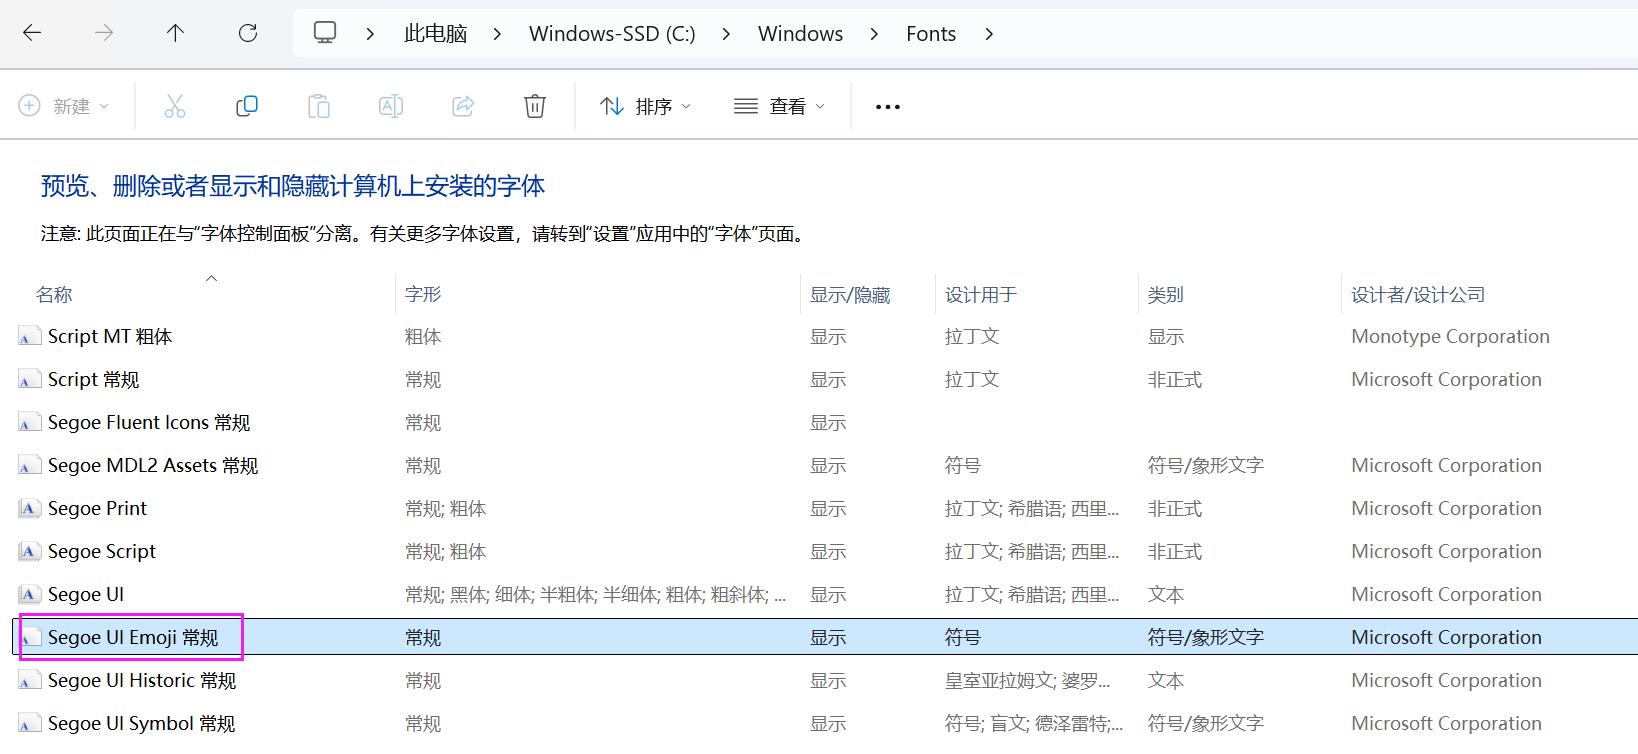
2. 用下面的代码找到Matplotlib 的字体目录， 位置一般在 `~/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/matplotlibrc`
   ```
   import matplotlib
   print(matplotlib.matplotlib_fname())
   ```
4. 把seguiemj.ttf从windows拷贝到你的Matplotlib 的字体目录 `cp /mnt/c/windows/fonts/seguiemj.ttf ~/miniconda3/lib/python3.12/site-packages/matplotlib/mpl-data/fonts/ttf`
   
5. 找到缓存目录，一般位于 `~/.cache/matplotlib`, 并删掉目录下的json文件, `rm ~/.cache/matplotlib/fontlist-v390.json`
   ```
   import matplotlib
   print(matplotlib.get_cachedir())
   ```
6. 重启你的jupyter服务。

---

## 三、🎯 第二阶段复盘

| 技能 | 对应篇章 |
|------|---------|
| Matplotlib 基础 | 第19篇 |
| 5种基础图表 | 第20篇 |
| 图表美化 | 第21篇 |
| Seaborn | 第22篇 |
| 分布探索 | 第23篇 |
| 关系探索 | 第24篇 |
| 多子图布局 | 第25篇 |
| Plotly 交互 | 第26篇 |
| 选图指南 | 第27篇 |

---

## 四、📁 作品集建议

把这份可视化报告整理好：
1. 保存为 PNG（高 DPI）
2. 配上 3~5 句说明文字
3. 整理到 Jupyter Notebook

两份作品集（第18篇的数据分析报告 + 这篇的可视化报告），已经可以展示完整的数据分析能力了。

---

## 下期预告

> **第 29 篇：描述性统计 — 均值 / 方差 / 偏度 / 峰度**
>
> 第二阶段收官！下一阶段是统计学基础。下篇从描述性统计开始——均值、方差、偏度、峰度，用数字刻画数据的「长相」。

---

*跟着小荷，数据分析路上不迷路～*
*（萧何运筹帷幄，我们可视化造势。第二阶段，完美收官！🎉）*
